In [2]:
import pandas as pd
import numpy as np
import os, sys
import matplotlib.pyplot as plt

In [3]:
#rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny

path = "./data/newyorker_caption_contest/data/"
dirs = os.listdir(path)
files = [os.path.join(path,i) for i in os.listdir(path) if os.path.isfile(os.path.join(path,i))]


df = pd.DataFrame()

for file in files:
    
    data = pd.read_csv(file, sep=',')
    data['contest_id'] = os.path.split(file)[-1]
    df = pd.concat([df, data])

df['contest_id'] = df['contest_id'].str.replace('.csv', '')  # Remove '.csv' from values
df.info()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 2292678 entries, 0 to 4957
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   rank            float64
 1   caption         object 
 2   mean            float64
 3   precision       float64
 4   votes           int64  
 5   not_funny       int64  
 6   somewhat_funny  int64  
 7   funny           int64  
 8   contest_id      object 
dtypes: float64(3), int64(4), object(2)
memory usage: 174.9+ MB
   rank                                            caption      mean  \
0   0.0          I'm a congressman--obstruction is my job.  1.913043   
1   1.0  I'm what they mean when they say, 'The middle ...  1.842105   
2   2.0                  Does this suit make me look flat?  1.711111   
3   3.0    When the right woman comes along, I'll know it.  1.625000   
4   4.0  I used to lie in the gutter, but then I quit d...  1.617647   

   precision  votes  not_funny  somewhat_funny  funny contest_id  
0   0.094022 

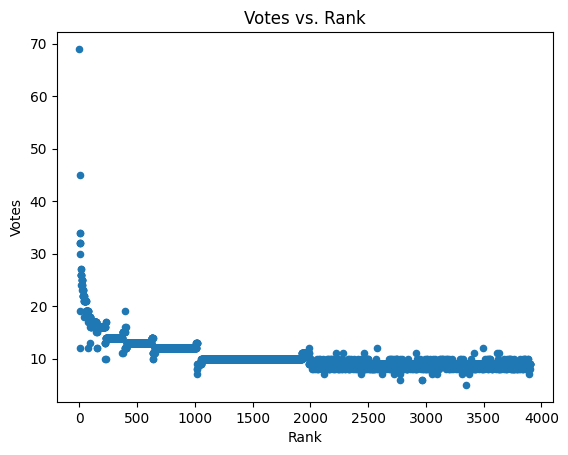

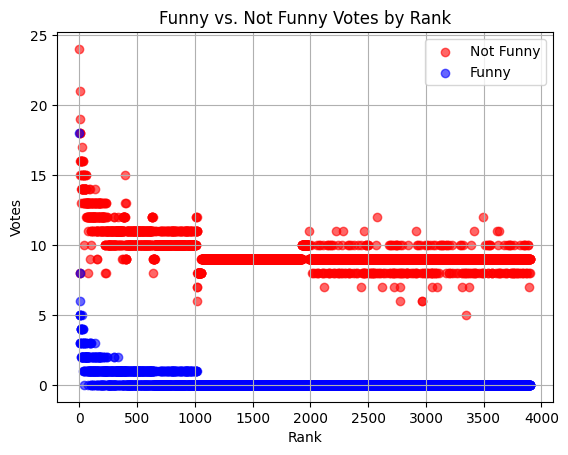

In [4]:
###OLD--->not used anymore
# Assuming 'df' is your DataFrame
df_filtered = df[df['contest_id'] == "510"]

# Creating the scatter plot
df_filtered.plot(kind='scatter', x='rank', y='votes', title='Votes vs. Rank', xlabel='Rank', ylabel='Votes')

# Show the plot
plt.show()


###next cell
# Scatter plot for "not funny" votes
plt.scatter(df_filtered['rank'], df_filtered['not_funny'], color='red', label='Not Funny', alpha=0.6)

# Scatter plot for "funny" votes
plt.scatter(df_filtered['rank'], df_filtered['funny'], color='blue', label='Funny', alpha=0.6)


# Adding titles and labels
plt.title('Funny vs. Not Funny Votes by Rank')
plt.xlabel('Rank')
plt.ylabel('Votes')
plt.legend()  # Show legend
plt.grid(True)  # Optional: Adding grid for better readability
plt.show()

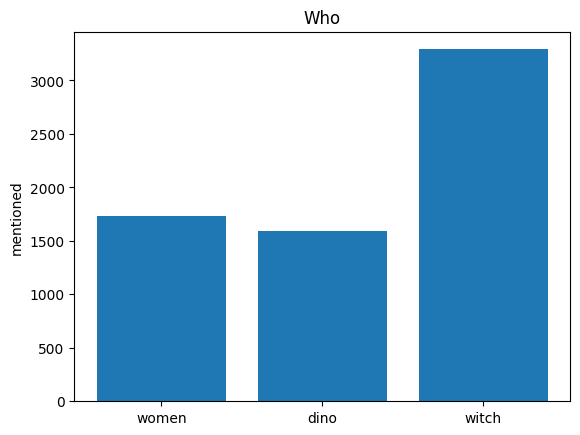

In [5]:
###OLD code--->not used anymore

women_count = df['caption'].str.contains('women').sum()

#print(df_filtered['caption'].str.contains('women').sum())

men_count = df['caption'].str.contains('men').sum() - women_count

dino_count = df['caption'].str.contains('dino').sum()

witch_count = df['caption'].str.contains('witch').sum()


fig, ax = plt.subplots()

words = ['women',  'dino', 'witch'] #had to remove men, cause its so much more
counts = [women_count, dino_count, witch_count]


ax.bar(words, counts)

ax.set_ylabel('mentioned')
ax.set_title('Who')


plt.show()



In [6]:
#word list to filter for certain toipcs:
women_filter = "women|woman|girl|mother|wife"  #words that imply a women appeared in the caption text (note: without pronouns cause we search explicit mentions)
men_filter = "men|man|boy|father|husband" #words that imply a men appear in the caption text (note: substract women_filter to avoid havind the cound for the word woMEN)
dino_filter = "dino|rex"
witch_filter = "witch|enchantress"


coutdict = {
  "women": "women|woman|girl|mother|wife",
  "men": "men|man|boy|father|husband",
  "dino": "dino|rex",
  "witch": "witch|enchantress",
  "trump": "trump|donald|president"
}

def do_counts(caption_array = df['caption'].copy(), who_count = {
  "women": "women|woman|girl|mother|wife",
  "men": "men|man|boy|father|husband",
  "dino": "dino|rex",
  "witch": "witch|enchantress"
}):
    #Count the words in all the captions of all the comics
    counted_dic = who_count.copy()
    counted = []
    for key, value in counted_dic.items():
        counted_dic[key] = (caption_array.str.contains(value).sum())
        counted.append(counted_dic[key])
    return counted

print(do_counts(df['caption'].copy(), coutdict))


[24891, 140493, 1987, 3292, 2985]


In [7]:
coutdict = {
  "women": "women|woman|girl|mother|wife",
  "men": "men|man|boy|father|husband",
  "dino": "dino|rex",
  "witch": "witch|enchantress",
  "trump": "trump|donald|president"
}


###Analyse the mentions over time

#find all IDs:
ids = np.array(df['contest_id'].copy().drop_duplicates())
all_counts = []

for i in range(len(ids)-1):
    df_ID = df[df['contest_id'] == str(ids[i])]
    all_counts.append(do_counts(df_ID['caption'].copy(), coutdict))
    
print(all_counts)

[[87, 275, 2, 3, 12], [121, 215, 1, 39, 4], [56, 255, 0, 0, 2], [36, 313, 5, 9, 9], [17, 201, 1, 7, 5], [26, 208, 0, 11, 7], [116, 294, 0, 21, 14], [36, 410, 0, 2, 2], [28, 305, 0, 8, 4], [29, 219, 0, 4, 6], [131, 252, 0, 6, 2], [79, 267, 0, 14, 8], [108, 437, 0, 3, 46], [46, 147, 0, 3, 3], [34, 173, 13, 18, 7], [95, 291, 0, 3, 13], [63, 244, 14, 3, 39], [9, 260, 39, 2, 9], [44, 159, 13, 2, 14], [25, 245, 8, 7, 10], [23, 202, 1, 8, 15], [45, 246, 1, 7, 4], [7, 821, 0, 1, 0], [29, 360, 0, 8, 11], [84, 182, 1, 6, 1], [159, 390, 2, 13, 6], [42, 504, 1, 6, 8], [35, 164, 0, 14, 5], [20, 169, 2, 5, 12], [42, 397, 0, 4, 16], [222, 472, 5, 8, 11], [69, 212, 1, 10, 29], [34, 289, 0, 5, 7], [23, 539, 2, 9, 54], [4, 235, 1, 5, 8], [47, 130, 3, 4, 10], [38, 175, 0, 7, 11], [41, 475, 0, 4, 9], [34, 707, 0, 3, 21], [30, 182, 1, 2, 64], [20, 153, 1, 30, 4], [113, 506, 1, 7, 38], [29, 153, 0, 2, 48], [39, 857, 1, 22, 7], [135, 206, 0, 7, 11], [148, 231, 4, 2, 6], [41, 167, 1, 7, 44], [7, 219, 1, 1, 4]

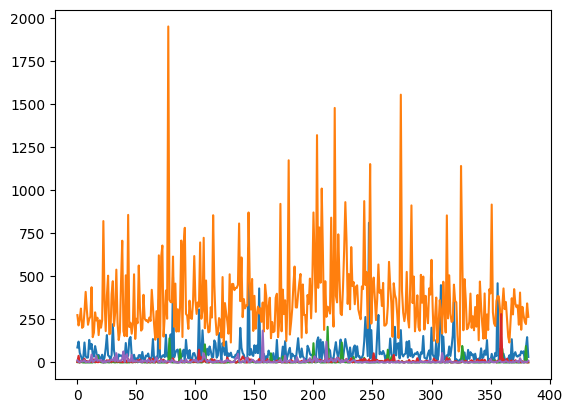

In [8]:
plt.plot(all_counts)
#all

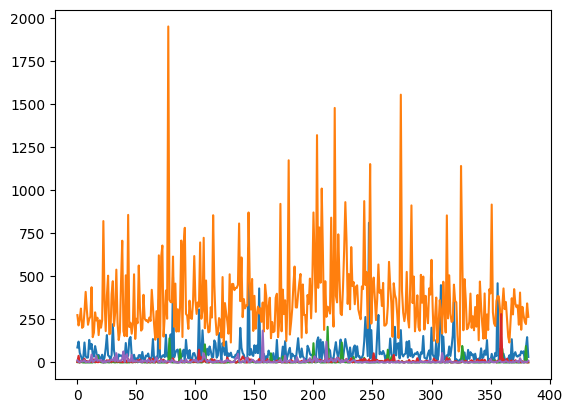

In [9]:
plt.plot(all_counts)
#trump

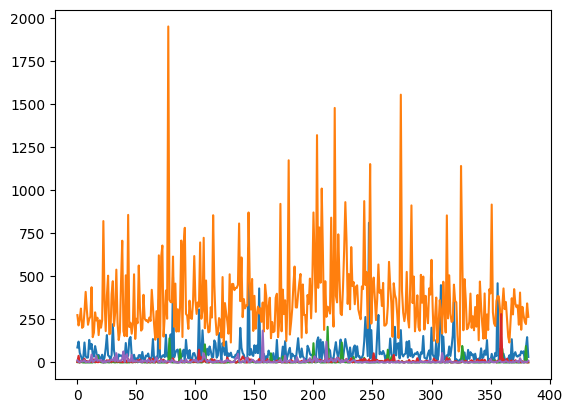

In [10]:
plt.plot(all_counts)
#trump, president, donald

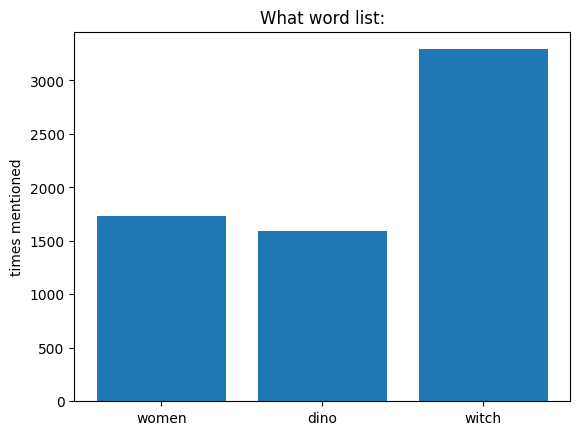

In [12]:
#plot the counts for all the data
fig, ax = plt.subplots()

words = ['women',  'dino', 'witch', 'men']#think about substracting women from men!!!!
ax.bar(words[:-1], counts)
ax.set_ylabel('times mentioned')
ax.set_title('What word list:')

plt.show()

In [13]:
df_filtered = df[df['contest_id'] == "510"]
df_filtered.head()

,rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny,contest_id
0,0.0,I'm a congressman--obstruction is my job.,1.913043,0.094022,69,24,27,18,510
1,1.0,"I'm what they mean when they say, 'The middle ...",1.842105,0.191381,19,8,6,5,510
2,2.0,Does this suit make me look flat?,1.711111,0.112915,45,21,16,8,510
3,3.0,"When the right woman comes along, I'll know it.",1.625000,0.116657,32,15,14,3,510
4,4.0,"I used to lie in the gutter, but then I quit d...",1.617647,0.133610,34,19,9,6,510


-----------------------------------------

In [ ]:
df.columns

Index(['rank', 'caption', 'mean', 'precision', 'votes', 'not_funny',
       'somewhat_funny', 'funny', 'contest_id'],
      dtype='object')

In [16]:
from src.utils.data_utils import count_terms, top_terms, plot_top_terms


In [19]:
top_captions = df.groupby('contest_id', group_keys=False).apply(
    lambda x: x.nlargest(50, 'votes'))
    
top_captions = top_captions['caption'].dropna().astype(str).tolist()

C:\Users\yunre\AppData\Local\Temp\ipykernel_10188\1203212495.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_captions = df.groupby('contest_id', group_keys=False).apply(


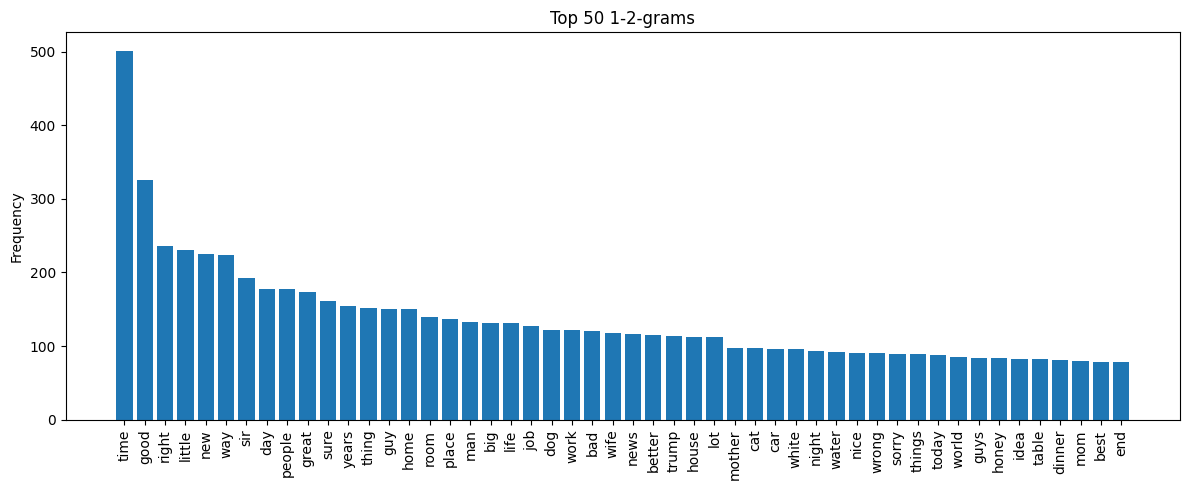

In [20]:
vocab, counts = count_terms(top_captions)
top_vocab, top_counts = top_terms(vocab, counts)
plot_top_terms(top_vocab, top_counts)